## Question 1: Text Generation using GRU

In [1]:
!pip install nltk torch matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import nltk
import time
import random
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [3]:
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

with open("input.txt", "r") as f:
    text = f.read().lower()

"""
Improvement:
Real dataset instead of small text
Better learning

"""

#Character-Level Preprocessing

chars = sorted(list(set(text)))
char2idx = {ch:i for i,ch in enumerate(chars)}
idx2char = {i:ch for ch,i in char2idx.items()}

encoded = [char2idx[c] for c in text]

seq_length = 50

X, Y = [], []

for i in range(len(encoded) - seq_length):
    X.append(encoded[i:i+seq_length])
    Y.append(encoded[i+seq_length])

X = torch.tensor(X[:10000])
Y = torch.tensor(Y[:10000])

--2026-04-10 03:10:54--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.1’

input.txt.1         100%[===================>]   1.06M  --.-KB/s    in 0.05s   

2026-04-10 03:10:54 (22.4 MB/s) - ‘input.txt.1’ saved [1115394/1115394]



In [4]:
split = int(0.9 * len(X))

X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

# GRU Model

In [5]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, hidden_size)

        self.gru = nn.GRU(
            hidden_size,
            hidden_size,
            batch_first=True,
            num_layers=2        # NEW (deeper model)
        )

        self.dropout = nn.Dropout(0.3)   # NEW (regularization)

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.gru(x)
        out = self.dropout(out[:, -1, :])   # apply dropout
        out = self.fc(out)

        return out

In [7]:
# Train model
model = GRUModel(len(chars), 128)   # inc hidden states
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)  ##better LR

for epoch in range(30):    ##more epochs
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, Y)
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 3.6698710918426514
Epoch 1, Loss: 3.5146360397338867
Epoch 2, Loss: 3.338118314743042
Epoch 3, Loss: 3.1678428649902344
Epoch 4, Loss: 3.129955768585205
Epoch 5, Loss: 3.07035756111145
Epoch 6, Loss: 3.030871629714966
Epoch 7, Loss: 2.9964964389801025
Epoch 8, Loss: 2.946850299835205
Epoch 9, Loss: 2.8937885761260986
Epoch 10, Loss: 2.8425848484039307
Epoch 11, Loss: 2.7952303886413574
Epoch 12, Loss: 2.7457966804504395
Epoch 13, Loss: 2.7019617557525635
Epoch 14, Loss: 2.651479959487915
Epoch 15, Loss: 2.5970797538757324
Epoch 16, Loss: 2.552722692489624
Epoch 17, Loss: 2.518320322036743
Epoch 18, Loss: 2.4744787216186523
Epoch 19, Loss: 2.4497170448303223
Epoch 20, Loss: 2.414883613586426
Epoch 21, Loss: 2.3878750801086426
Epoch 22, Loss: 2.3582024574279785
Epoch 23, Loss: 2.3326380252838135
Epoch 24, Loss: 2.3075647354125977
Epoch 25, Loss: 2.2839913368225098
Epoch 26, Loss: 2.268197774887085
Epoch 27, Loss: 2.240875482559204
Epoch 28, Loss: 2.220580816268921
Epoch 29

In [8]:
# Text Generation
def generate(model, start="the", length=50):
    model.eval()
    input_seq = [char2idx[c] for c in start]

    for _ in range(length):
        inp = torch.tensor([input_seq[-seq_length:]])
        out = model(inp)
        pred = torch.argmax(out).item()
        input_seq.append(pred)

    return ''.join([idx2char[i] for i in input_seq])

print(generate(model))

the the the the the the the the the the the the the t


#Q2: POS Tagging (GRU + LSTM)

In [9]:
sentences = ["I love NLP", "Deep learning is fun"]
tokens = [nltk.word_tokenize(s) for s in sentences]
tags = [nltk.pos_tag(t) for t in tokens]

words = list(set([w for sent in tokens for w in sent]))
pos_tags = list(set([t for sent in tags for _,t in sent]))

word2idx = {w:i for i,w in enumerate(words)}
tag2idx = {t:i for i,t in enumerate(pos_tags)}

In [10]:
# Add padding token to word2idx and tag2idx
padding_word_idx = len(words)
padding_tag_idx = len(pos_tags)
word2idx['<pad>'] = padding_word_idx
tag2idx['<pad>'] = padding_tag_idx

# Find max sequence length
max_seq_len = max(len(s) for s in tokens)

X_padded = []
Y_padded = []

for sent, tag_list in zip(tokens, tags):
    encoded_x = [word2idx[w] for w in sent]
    encoded_y = [tag2idx[t] for _,t in tag_list]

    # Pad sequences
    padded_x = encoded_x + [padding_word_idx] * (max_seq_len - len(encoded_x))
    padded_y = encoded_y + [padding_tag_idx] * (max_seq_len - len(encoded_y))

    X_padded.append(padded_x)
    Y_padded.append(padded_y)

X = torch.tensor(X_padded)
Y = torch.tensor(Y_padded)


# LSTM Model

In [16]:
class LSTMTagger(nn.Module):
    def __init__(self, vocab_size, tagset_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 64)
        # Fixed dropout here: should be a float and initialized as a layer
        self.lstm = nn.LSTM(64, 64, batch_first=True, num_layers = 2, dropout = 0.3)
        self.fc = nn.Linear(64, tagset_size)
        # Added dropout layer for regularization
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = self.dropout(out)
        return self.fc(out)

In [17]:
model = LSTMTagger(len(word2idx), len(tag2idx))
optimizer = optim.Adam(model.parameters(), lr=0.003)
criterion = nn.CrossEntropyLoss()
X_train_tensor = torch.tensor(X_padded)
Y_train_tensor = torch.tensor(Y_padded)

for epoch in range(20):
    optimizer.zero_grad()
    out = model(X_train_tensor)
    loss = criterion(out.view(-1, len(tag2idx)), Y_train_tensor.view(-1))
    loss.backward()
    optimizer.step()
    print(loss.item())

1.9551475048065186
1.9266771078109741
1.9039181470870972
1.8828113079071045
1.8775694370269775
1.8211157321929932
1.7528735399246216
1.7370461225509644
1.6951743364334106
1.6336959600448608
1.597278356552124
1.5469286441802979
1.453344702720642
1.4230196475982666
1.3721380233764648
1.2796114683151245
1.175830364227295
1.1964341402053833
1.1879856586456299
1.0327848196029663


# Q3: Compare RNN, LSTM, GRU

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training RNN...
Epoch 1/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 19s 70ms/step - accuracy: 0.0285 - loss: 6.7272 - val_accuracy: 0.0298 - val_loss: 6.7076
Epoch 2/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 17s 74ms/step - accuracy: 0.0403 - loss: 6.5131 - val_accuracy: 0.0577 - val_loss: 6.4125
Epoch 3/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - accuracy: 0.0736 - loss: 6.0097 - val_accuracy: 0.0862 - val_loss: 6.1805
Epoch 4/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.1008 - loss: 5.6242 - val_accuracy: 0.1066 - val_loss: 6.1330
Epoch 5/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.1191 - loss: 5.3700 - val_accuracy: 0.1058 - val_loss: 6.1048
Epoch 6/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.1339 - loss: 5.1536 - val_accuracy: 0.1104 - val_loss: 6.1112
Epoch 7/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.1440 - loss: 4.9513 - val_accuracy: 0.1111 - val_loss: 6.1034
Epoch 8/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.1562 -

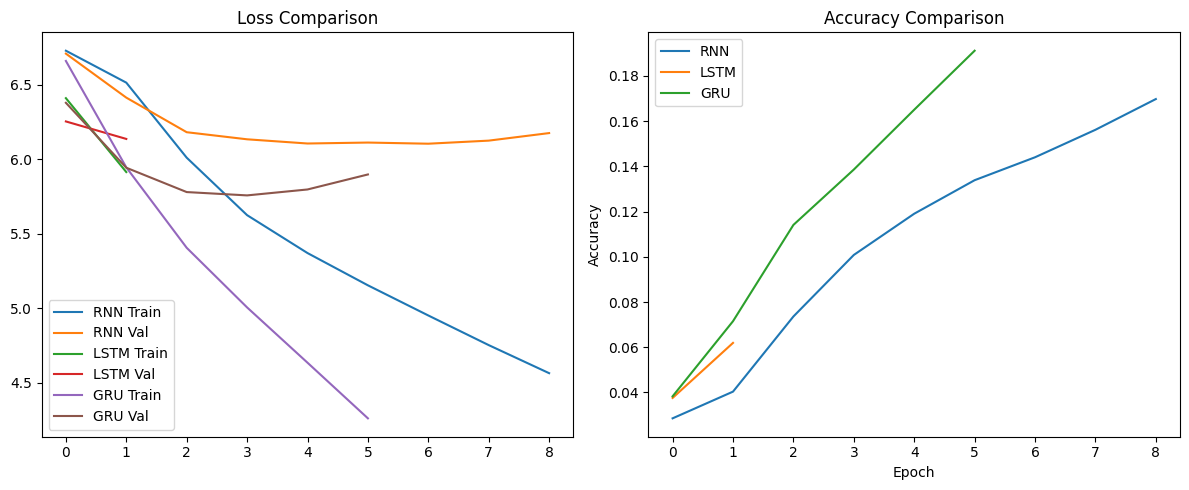


Final Accuracy:
RNN: 0.11109592765569687
LSTM: 0.05097021162509918
GRU: 0.11956819146871567

RNN Output:
she was no who had it all his life he is long

LSTM Output:
she was struck more much woodhouse's case him with thought every at

GRU Output:
she was written to miss given into churchill as you should persuaded


In [18]:
import numpy as np
import tensorflow as tf
import nltk
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU
import matplotlib.pyplot as plt

# -------------------------------
# Load dataset
# -------------------------------
nltk.download('gutenberg')
text = nltk.corpus.gutenberg.raw('austen-emma.txt').lower()

# 🔥 LIMIT DATA (IMPORTANT)
text = text[:200000]

# -------------------------------
# Tokenization
# -------------------------------
vocab_size = 5000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts([text])

total_words = vocab_size   # 🔥 FIX HERE

sequences = tokenizer.texts_to_sequences([text])[0]

# -------------------------------
# Create sequences
# -------------------------------
seq_len = 20
input_sequences = []

for i in range(seq_len, len(sequences)):
    input_sequences.append(sequences[i-seq_len:i+1])

input_sequences = np.array(input_sequences)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = tf.keras.utils.to_categorical(y, num_classes=total_words)

# NEW: Split data into training and testing sets for Q3
split_index = int(0.8 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# -------------------------------
# Model builder
# -------------------------------
# def build_model(cell_type):
#     model = tf.keras.Sequential([
#         tf.keras.layers.Embedding(total_words, 64, input_length=seq_len),
#         cell_type(128),
#         tf.keras.layers.Dense(total_words, activation='softmax')
#     ])
#     model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
#     return model
def build_model(cell_type):
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(total_words, 128, input_length=seq_len),  # 🔥 increased

        cell_type(128, return_sequences=False),  # explicitly defined

        tf.keras.layers.Dropout(0.3),  # NEW

        tf.keras.layers.Dense(total_words, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.003),  # tuned LR
        metrics=['accuracy']
    )

    return model
# -------------------------------
# Build models
# -------------------------------
rnn_model = build_model(SimpleRNN)
lstm_model = build_model(LSTM)
gru_model = build_model(GRU)


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)


# -------------------------------
# Train models
# -------------------------------
print("Training RNN...")
rnn_hist = rnn_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

print("Training LSTM...")
lstm_hist = lstm_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

print("Training GRU...")
gru_hist = gru_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# -------------------------------
# Plot loss
# -------------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(rnn_hist.history['loss'], label='RNN Train')
plt.plot(rnn_hist.history['val_loss'], label='RNN Val')

plt.plot(lstm_hist.history['loss'], label='LSTM Train')
plt.plot(lstm_hist.history['val_loss'], label='LSTM Val')

plt.plot(gru_hist.history['loss'], label='GRU Train')
plt.plot(gru_hist.history['val_loss'], label='GRU Val')

plt.legend()
plt.title("Loss Comparison")

# -------------------------------
# Plot accuracy
# -------------------------------
plt.subplot(1, 2, 2)
plt.plot(rnn_hist.history['accuracy'], label='RNN')
plt.plot(lstm_hist.history['accuracy'], label='LSTM')
plt.plot(gru_hist.history['accuracy'], label='GRU')
plt.legend()
plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# -------------------------------
# Text generation function
# -------------------------------
index_word = {v: k for k, v in tokenizer.word_index.items()}

def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = token_list[-seq_len:]
        token_list = pad_sequences([token_list], maxlen=seq_len, padding='pre')

        preds = model.predict(token_list, verbose=0)[0]

        # Sampling instead of argmax
        preds = np.asarray(preds).astype('float64')
        preds = preds / np.sum(preds)
        predicted = np.random.choice(len(preds), p=preds)

        word = index_word.get(predicted, "")
        seed_text += " " + word

    return seed_text

print("\nFinal Accuracy:")
print("RNN:", rnn_model.evaluate(X_test, y_test, verbose=0)[1])
print("LSTM:", lstm_model.evaluate(X_test, y_test, verbose=0)[1])
print("GRU:", gru_model.evaluate(X_test, y_test, verbose=0)[1])

# -------------------------------
# Generate samples
# -------------------------------
print("\nRNN Output:")
print(generate_text(rnn_model, "she was"))

print("\nLSTM Output:")
print(generate_text(lstm_model, "she was"))

print("\nGRU Output:")
print(generate_text(gru_model, "she was"))